In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import entropy
import missingno as msno

In [2]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [3]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index, 
                palette=palette, ax=ax, legend=False)
    
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

plt.show()

In [4]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [5]:
pokemon_df = pd.read_csv('../Actividad 1/Pokemon.csv')

In [6]:
# 1. CARGA DE DATOS Y CONVERSIÓN DE TIPOS

# Conversion categóricas a "category" y booleana a "bool"
pokemon_df['Type 1'] = pokemon_df['Type 1'].astype('category')
pokemon_df['Type 2'] = pokemon_df['Type 2'].astype('category')
pokemon_df['Generation'] = pokemon_df['Generation'].astype('category')
pokemon_df['Legendary'] = pokemon_df['Legendary'].astype('bool')

print(f"Dimensiones del dataset: {pokemon_df.shape}")
print("\nInformacion de tipos y nulos:")
pokemon_df.info()

Dimensiones del dataset: (800, 13)

Informacion de tipos y nulos:
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   #           800 non-null    int64   
 1   Name        800 non-null    str     
 2   Type 1      800 non-null    category
 3   Type 2      414 non-null    category
 4   Total       800 non-null    int64   
 5   HP          800 non-null    int64   
 6   Attack      800 non-null    int64   
 7   Defense     800 non-null    int64   
 8   Sp. Atk     800 non-null    int64   
 9   Sp. Def     800 non-null    int64   
 10  Speed       800 non-null    int64   
 11  Generation  800 non-null    category
 12  Legendary   800 non-null    bool    
dtypes: bool(1), category(3), int64(8), str(1)
memory usage: 59.8 KB


In [7]:
# 2. EXPLORACION DE VARIABLES CATEGORICAS Y ENTROPIA
print("\n--- RESUMEN CATEGORICO ---")
display(pokemon_df.describe(include=['category', 'bool']))


--- RESUMEN CATEGORICO ---


,Type 1,Type 2,Generation,Legendary
count,800,414,800,800
unique,18,18,6,2
top,Water,Flying,1,False
freq,112,97,166,735


In [8]:
# Calculo de Entropia de Shannon para 'Type 1'
type1_counts = pokemon_df['Type 1'].value_counts() #cuenta la cantidad de pokemones por tipo
type1_probs = type1_counts / type1_counts.sum() #convierte esaa ceuntas en probabilidades dividiendo por el total de pokemones
#Entropia maxima
H_max = np.log2(pokemon_df['Type 1'].nunique()) #es el escenario de entropia maxima, es decir, si todos los tipos tuvieran la misma cantidad de pokemones, la entropia seria H_max
#Entropia de shanon con Scipy
H_shannon = entropy(type1_probs, base=2) #indica el nivel de incertidumbre o desorden en la distribución de los tipos de Pokémon. Si H_shannon es cercano a H_max, significa que los Pokémon están distribuidos de manera más uniforme entre los tipos. Si H_shannon es mucho menor que H_max, significa que la distribución está más concentrada en unos pocos tipos.

print(f"\nEntropia Type 1: {H_shannon:.2f} | Entropía Máxima H_max: {H_max:.2f}")

#sirve para ver si los pokemon están distribuidos de forma pareja entre todos los tipos, o casi todos se concentran en unos pocos tipos


Entropia Type 1: 3.92 | Entropía Máxima H_max: 4.17


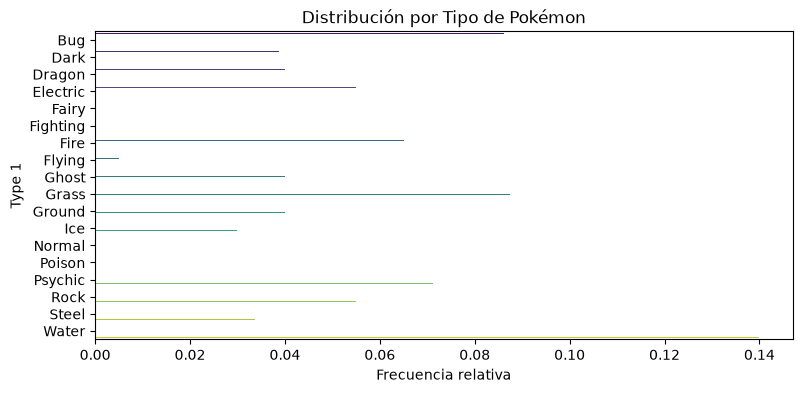

In [18]:
# Graficos de frecuencias categoricas
plot_frecuencias_relativas(pokemon_df, 'Type 1', title='Distribución por Tipo de Pokémon')

In [6]:
# 3. ANALISIS DE DATOS FALTANTES (MISSINGNO)
print("\n--- ANALISIS DE DATOS FALTANTES ---")
faltantes = pokemon_df.isna().sum() # Cuenta la cantidad de valores faltantes por columna, .isna() evalúa celda por celda y devuelve True si hay un valor nulo (NaN) y False si hay un dato válido, .sum suma los True de cada columna, devolviendo la cantidad de valores faltantes por columna
faltantes_df = pd.DataFrame({ #Une ambas métricas (el conteo y el porcentaje) en una nueva estructura ordenada de tipo DataFrame de dos columnas.
    'faltantes': faltantes, 
    'porcentaje': (faltantes / len(pokemon_df) * 100).round(2)
})
print(faltantes_df[faltantes_df['faltantes'] > 0]) # Muestra solo las columnas con valores faltantes


--- ANALISIS DE DATOS FALTANTES ---
        faltantes  porcentaje
Type 2        386       48.25


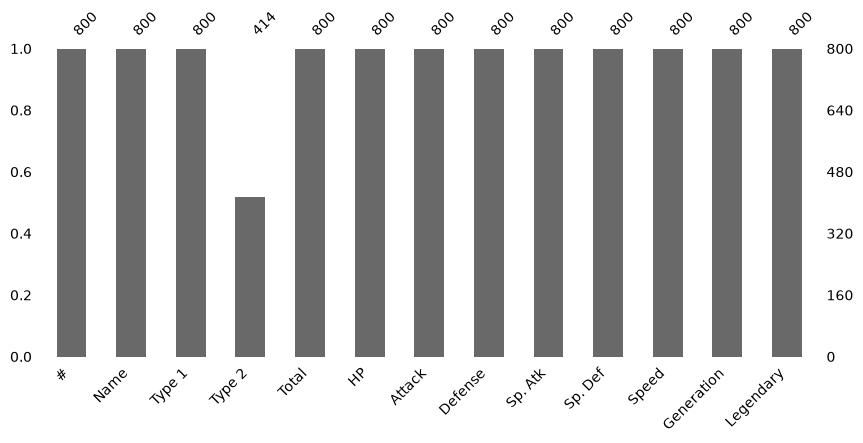

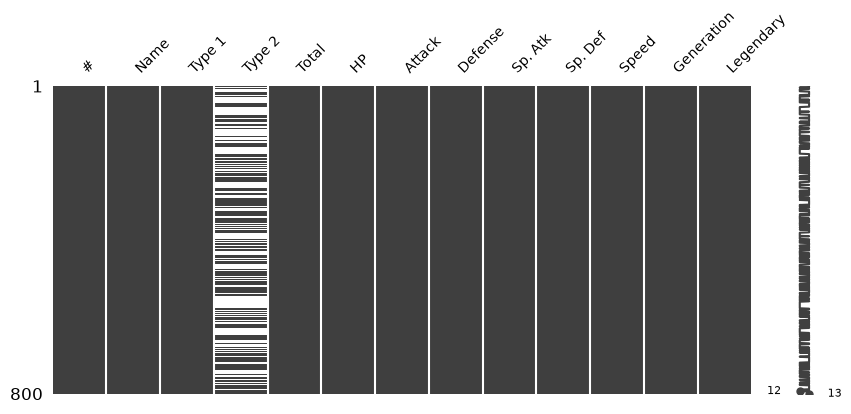

In [7]:
# Matriz y barra de valores nulos
msno.bar(pokemon_df, figsize=(10, 4), fontsize=10) #Muestra una barra vertical por cada columna del dataset representando la cantidad de datos presentes(no nulos)
plt.show()

msno.matrix(pokemon_df, figsize=(10, 4), fontsize=10) #Muestra una matriz donde cada fila representa un registro y cada columna representa una variable. Los valores presentes se muestran en blanco y los valores faltantes se muestran en negro. Esto permite identificar patrones de datos faltantes y relaciones entre variables.
plt.show()

In [12]:
# Faltantes en Type 2 por Generación y Estado Legendario
def nulos_por_grupo(df, grupo_cols, target_col): #grupo_cols: La columna (o lista de columnas) por la que se va a agrupar(Generation), target_col: La columna donde se va a evaluar los nulos (Type 2).
    return df.groupby(grupo_cols, observed=True)[target_col].apply(lambda x: x.isnull().mean() * 100).reset_index(name='pct_nulos')
    #x.isnull() genera una lista de verdaderos y falsos (True si es nulo, False si tiene tipo).
    #El truco clave — .mean(): En Python, los valores booleanos se tratan como números (True = 1, False = 0). Al calcular el promediar (.mean()) de estos unos y ceros, se obtiene exactamente la proporción de nulos.
    #* 100: Convierte esa proporción (ej. 0.45) en un porcentaje directo (45%).

print("\nPorcentaje de Pokemon monotipo (Type 2 nulo) por Generacion:")
display(nulos_por_grupo(pokemon_df, ['Generation'], 'Type 2')) #muestra la tabla resultante de la funcion nulos_por_grupo, que indica el porcentaje de pokemones monotipo (sin segundo tipo) por generación

#sirve para descubrir si la proporcion de pokemon monotipo (sin segundo tipo) ha cambiado a lo largo de las distintas generaciones del juego


Porcentaje de Pokemon monotipo (Type 2 nulo) por Generacion:


,Generation,pct_nulos
0,1,53.012048
1,2,48.113208
2,3,48.750000
3,4,44.628099
4,5,50.303030
5,6,39.024390


In [13]:
# 4. ESTADISTICA DESCRIPTIVA DE VARIABLES NUMERICAS
cols_numericas = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# SciPy describe avanzado
ed_pokemon = st.describe(pokemon_df[cols_numericas])
ed_pokemon_df = pd.DataFrame({
    'Observaciones': ed_pokemon.nobs,
    'Min': ed_pokemon.minmax[0],
    'Max': ed_pokemon.minmax[1],
    'Media': ed_pokemon.mean,
    'Varianza': ed_pokemon.variance,
    'Asimetría': ed_pokemon.skewness,
    'Curtosis': ed_pokemon.kurtosis
}, index=cols_numericas)

print("\nEstadistica descriptiva avanzada (SciPy):")
display(ed_pokemon_df)


Estadistica descriptiva avanzada (SciPy):


,Observaciones,Min,Max,Media,Varianza,Asimetría,Curtosis
HP,800,1,255,69.25875,652.019323,1.565282,7.179466
Attack,800,5,190,79.00125,1053.480599,0.550579,0.161168
Defense,800,5,230,73.84250,972.410707,1.153744,2.701760
Sp. Atk,800,10,194,72.82000,1070.748536,0.743266,0.288544
Sp. Def,800,20,230,71.90250,774.448554,0.852416,1.610744
Speed,800,5,180,68.27750,844.511133,0.357262,-0.242452


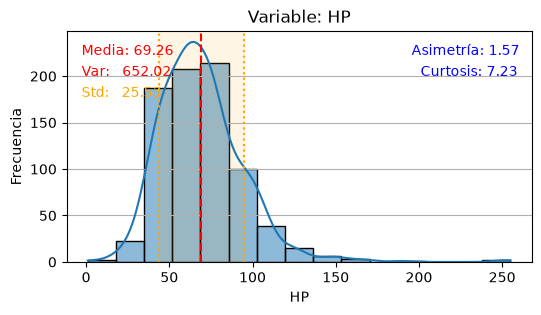

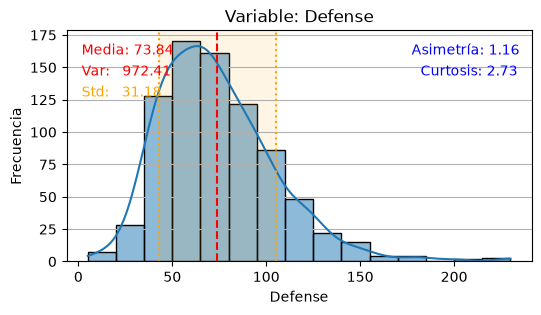

In [8]:
plot_histograma(pokemon_df, 'HP', snk=True)
plot_histograma(pokemon_df, 'Defense', snk=True)

In [15]:
# 5. DETECCIÓN Y ANALISIS DE OUTLIERS
# Método  de rango intercuartil para detectar outliers
cols_outliers = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
Q1 = pokemon_df[cols_outliers].quantile(0.25) 
Q3 = pokemon_df[cols_outliers].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR 
limite_sup = Q3 + 1.5 * IQR

print("\n--- OUTLIERS DETECTADOS (MÉTODO IQR) ---")
for col in cols_outliers:
    outliers = pokemon_df[(pokemon_df[col] < limite_inf[col]) | (pokemon_df[col] > limite_sup[col])]
    print(f"{col}: {len(outliers)} outliers identficados")

#sirve para identificar los pokemon que tienen valores atipicos en sus estadisticas, lo que podria indicar que son especialmente fuertes o debiles en comparacion con la mayoria de los pokemon. Esto es útil para analisis de balance de juego o para identificar pokemon unicos.


--- OUTLIERS DETECTADOS (MÉTODO IQR) ---
HP: 19 outliers identficados
Attack: 7 outliers identficados
Defense: 13 outliers identficados
Sp. Atk: 10 outliers identficados
Sp. Def: 7 outliers identficados
Speed: 2 outliers identficados


In [16]:
# Metodo Regla de 3 Desviaciones Estándar (3 SD)
mean = pokemon_df[cols_outliers].mean()
std = pokemon_df[cols_outliers].std()
#Calcula el promedio (mu) y la desviación estándar (sigma) de cada una de las 6 columnas de combate (HP, Attack, Defense, etc.).
outliers_3sd = (pokemon_df[cols_outliers] < (mean - 3 * std)) | (pokemon_df[cols_outliers] > (mean + 3 * std))
#Crea las fronteras de tolerancia: [mu - 3*sigma, mu + 3*sigma].Compara celda por celda para verificar si el valor de la estadística cae por debajo de la media menos 3 desvíos O (|) por encima de la media más 3 desvíos.Esto genera una tabla de booleanos (True/False) donde cada True representa un outlier según esta regla.
print(f"\nTotal de filas con al menos un valor extremo (|Z| > 3): {outliers_3sd.any(axis=1).sum()}")
#any(axis=1): Examina cada fila (cada Pokémon individual) y devuelve True si tiene al menos un True en cualquiera de sus 6 columnas de combate.
#.sum(): Cuenta cuántos Pokémon en total cumplen esa condición de tener al menos un valor extremo en su perfil de estadísticas.


Total de filas con al menos un valor extremo (|Z| > 3): 32


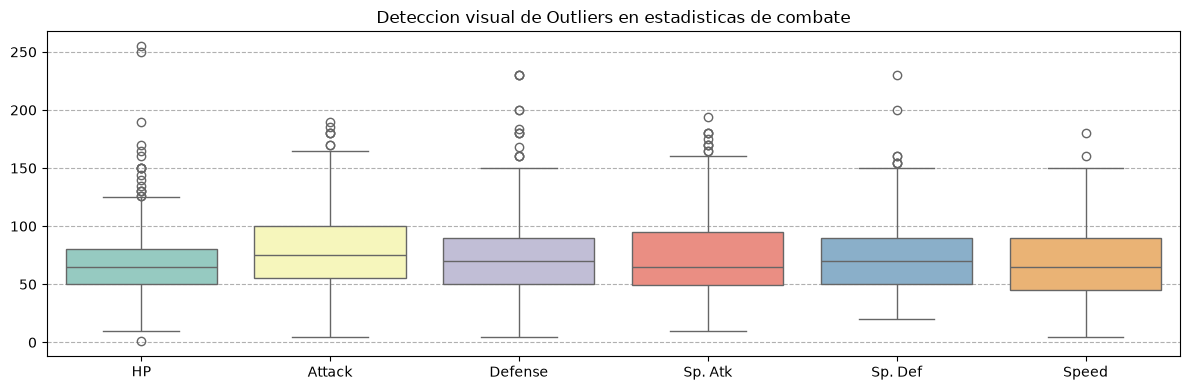

In [17]:
# Visualizacion de Boxplots de características de combate
plt.figure(figsize=(12, 4))
sns.boxplot(data=pokemon_df[cols_outliers], palette='Set3')
plt.title('Deteccion visual de Outliers en estadisticas de combate')
plt.grid(axis='y', ls='--')
plt.tight_layout()
plt.show()

#Sirve para confirmar de forma visual los límites analíticos que se calculo previamente con el método IQR

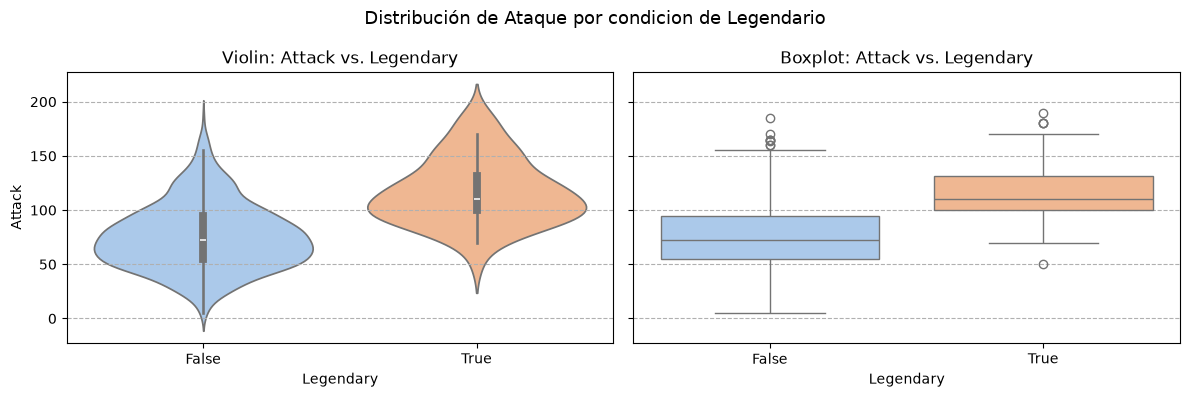

In [18]:
# 6. RELACIONES ENTRE VARIABLES
#Numérica-Categórica: Violin y Boxplot
plot_violin_box(pokemon_df, num_col='Attack', cat_col='Legendary', title='Distribución de Ataque por condicion de Legendario') # sirve para ver si los Pokémon legendarios teiene mas ataque que los normales y que tan grande es esa diferencia

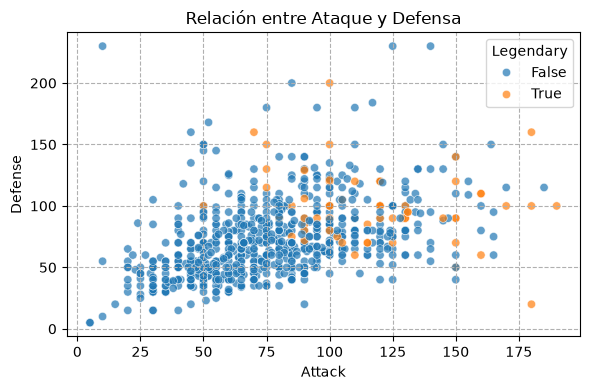

In [19]:
# Numérica-Numérica: Scatterplot
plt.figure(figsize=(6, 4)) # Configura el tamaño de la figura
sns.scatterplot(data=pokemon_df, x='Attack', y='Defense', hue='Legendary', alpha=0.7) # Crea un gráfico de dispersión
plt.grid(ls='--') # Configura la cuadrícula del gráfico
plt.title('Relación entre Ataque y Defensa')
plt.tight_layout() # Ajusta el diseño para que no se solapen los elementos
plt.show() 
#sirve para ver si un pokemon con mucho ataque suele tener tambien mucha defensa o si son estadisticas independientes

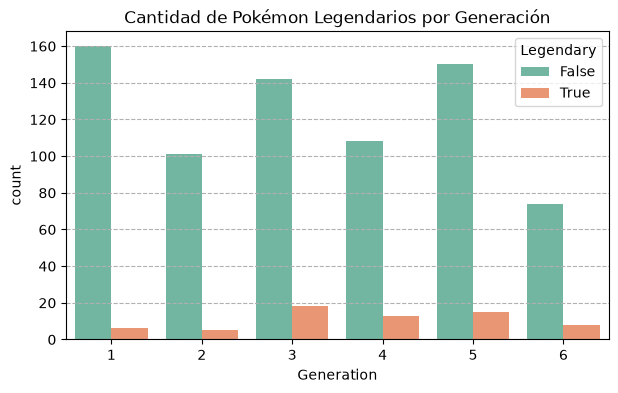

In [20]:
#Categórica-Categórica: Grafico de barras
plt.figure(figsize=(7, 4))
sns.countplot(x='Generation', hue='Legendary', data=pokemon_df, palette='Set2') # Crea un gráfico de barras para mostrar la cantidad de pokemon legendarios por generación
plt.grid(ls='--', axis='y') # Configura la cuadrícula del gráfico solo en el eje y
plt.title("Cantidad de Pokémon Legendarios por Generación")
plt.show()
#sirve para ver como se distribuye la cantidad de Pokémon normales y legendarios a lo largo de las distintas generaciones